# **Task 4.4 Supervised Learning - Classification and hyperparameter tuning**
by Sneha Sivakaran

In [3]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [11]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/cox2.csv',
index_col=0)
print(df.shape)
df.head()

(462, 256)


,QikProp_.amine,QikProp_.acid,QikProp_.rotor,QikProp_.rctvFG,QikProp_CNS,QikProp_MW,QikProp_dipole,QikProp_SASA,QikProp_FOSA,QikProp_FISA,...,moe2D_vsa_acc,moe2D_vsa_don,moe2D_vsa_hyd,moe2D_vsa_other,moe2D_vsa_pol,moe2D_weinerPath,moe2D_weinerPol,moe2D_zagreb,IC50,cox2Class
QikProp_.stars,,,,,,,,,,,,,,,,,,,,,
1,0,0,1,0,0,358.882,7.645,635.022,273.363,75.583,...,32.02,0.00,268.2,6.513,0.0,1340,37,138,0.001,Inactive
0,0,0,2,0,-1,359.870,7.959,622.548,189.930,136.949,...,32.02,20.14,236.8,10.110,0.0,1340,37,138,0.001,Inactive
0,0,0,3,0,-1,355.451,7.500,610.972,268.526,136.952,...,34.52,20.14,238.4,18.560,0.0,1524,39,142,0.001,Inactive
1,0,0,2,0,-1,393.423,9.342,651.852,190.772,136.955,...,32.02,20.14,249.7,10.110,0.0,1898,43,156,0.001,Inactive
1,0,0,2,0,-1,394.315,9.409,637.688,189.933,136.952,...,32.02,20.14,255.1,10.110,0.0,1486,40,144,0.001,Inactive


# Define Features & Target

In [12]:
# Target: cox2Class = Active or Inactive
# Drop IC50 since cox2Class is derived from it
X = df.drop(columns=['cox2Class', 'IC50'])
y = LabelEncoder().fit_transform(df['cox2Class'])  # Active=0, Inactive=1

print("Features:", X.shape[1])
print("Class distribution:", dict(zip(['Active','Inactive'], [sum(y==0), sum(y==1)])))

Features: 254
Class distribution: {'Active': np.int64(90), 'Inactive': np.int64(372)}


# Split Dataset (75/25)

In [13]:
# Split into 75% training and 25% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 346
Test samples: 116


# Preprocessing (Scaling)

In [14]:
# Scale features: fit on training data only, then apply to test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter Tuning with GridSearchCV (10-fold CV)

In [15]:
# Define hyperparameter grid to search over
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# GridSearchCV tries all combinations with 10-fold cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_.round(4))

Best parameters: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 100}
Best CV ROC-AUC: 0.8153


# Feature Importances

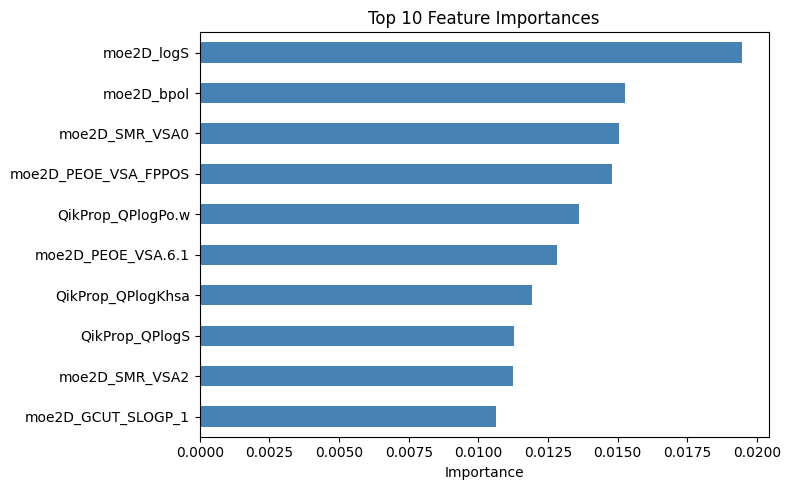

In [16]:
# Use the best model found by GridSearchCV
model = grid_search.best_estimator_

# Show the 10 most important features
importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# Evaluate on Test Set

Accuracy:      0.8362
Cohen's Kappa: 0.3456
ROC-AUC:       0.8518


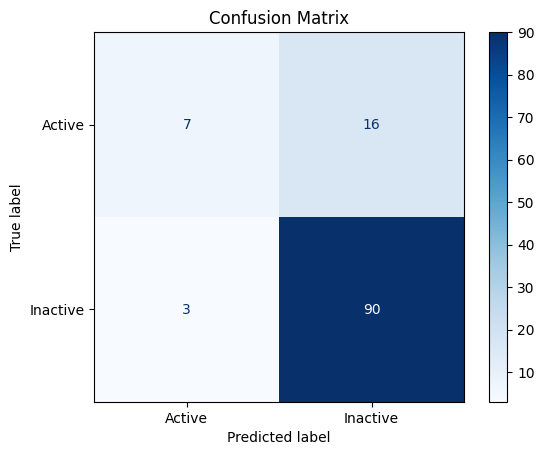

In [17]:
# Apply final model to test set and evaluate performance
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:     ", round(accuracy_score(y_test, y_pred), 4))
print("Cohen's Kappa:", round(cohen_kappa_score(y_test, y_pred), 4))
print("ROC-AUC:      ", round(roc_auc_score(y_test, y_prob), 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Active', 'Inactive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Interpretation
The Random Forest Classifier predicts whether a COX-2 compound is Active or Inactive based on 255 molecular features. I used GridSearchCV with 10-fold cross-validation to find the best hyperparameters. Since the classes are a bit imbalanced, I used ROC-AUC as the main metric instead of just accuracy. Cohen's Kappa also gives a better idea of model performance since it accounts for random chance. The most important features are mainly molecular descriptors related to the compound's structure which makes sense for predicting biological activity.